In [3]:
import pandas as pd
import numpy as np

# 1. Load the data
df = pd.read_csv('data/telco.csv') # or 'telco.csv' depending on your path

# 2. Convert 'Total Charges' to numeric (handles any blank spaces or missing values)
df['Total Charges'] = pd.to_numeric(df['Total Charges'], errors='coerce').fillna(0)

# 3. Drop non-predictive location & ID columns that aren't useful for machine learning
columns_to_drop = [
    'Customer ID', 'Country', 'State', 'City', 'Zip Code', 
    'Latitude', 'Longitude', 'Quarter', 'Customer Status', 
    'Churn Score', 'Churn Category', 'Churn Reason'
]
# Drop only the ones that exist in the DataFrame
df.drop(columns=[col for col in columns_to_drop if col in df.columns], inplace=True)

# 4. Separate target variable (Churn Label) and features
X = df.drop('Churn Label', axis=1)
y = df['Churn Label'].map({'Yes': 1, 'No': 0}) # Convert 'Yes'/'No' to 1/0

# 5. One-Hot Encode categorical features
X = pd.get_dummies(X, drop_first=True)

print("Data successfully processed! Feature matrix shape:", X.shape)

Data successfully processed! Feature matrix shape: (7043, 43)


In [4]:
from sklearn.model_selection import train_test_split

# 1. Clean up columns that cause data leakage or are redundant identifiers
leakage_and_id_cols = [
    'Customer ID', 'Country', 'State', 'City', 'Zip Code', 
    'Latitude', 'Longitude', 'Quarter', 'Customer Status', 
    'Churn Score', 'Churn Category', 'Churn Reason', 'Satisfaction Score'
]

# Drop columns that exist in the dataframe
df_clean = df.drop(columns=[col for col in leakage_and_id_cols if col in df.columns])

# 2. Separate Features (X) and Target (y)
X = df_clean.drop('Churn Label', axis=1)
y = df_clean['Churn Label'].map({'Yes': 1, 'No': 0})

# 3. Convert all categorical columns into 1s and 0s using One-Hot Encoding
X = pd.get_dummies(X, drop_first=True)

# 4. Split data: 80% Training, 20% Testing (stratified so churn ratios remain identical)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training set shape: {X_train.shape}")
print(f"Testing set shape: {X_test.shape}")

Training set shape: (5634, 42)
Testing set shape: (1409, 42)


In [5]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
import xgboost as xgb

# 1. Logistic Regression (Baseline)
log_reg = LogisticRegression(max_iter=1000)
log_reg.fit(X_train, y_train)

# 2. Random Forest Classifier
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

# 3. XGBoost Classifier (Usually performs best on tabular data)
xgb_model = xgb.XGBClassifier(n_estimators=100, learning_rate=0.05, max_depth=5, random_state=42, eval_metric='logloss')
xgb_model.fit(X_train, y_train)

print("All models trained successfully!")

/Users/seemasultana/churn-prediction/churn_env/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: divide by zero encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/seemasultana/churn-prediction/churn_env/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: overflow encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/seemasultana/churn-prediction/churn_env/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: invalid value encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/seemasultana/churn-prediction/churn_env/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:330: RuntimeWarning: divide by zero encountered in matmul
  grad[:n_features] = X.T @ grad_pointwise + l2_reg_strength * weights
/Users/seemasultana/churn-prediction/churn_env/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:330: RuntimeWar

All models trained successfully!


In [6]:
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

models = {
    "Logistic Regression": log_reg,
    "Random Forest": rf_model,
    "XGBoost": xgb_model
}

for name, model in models.items():
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]
    
    auc = roc_auc_score(y_test, y_proba)
    print(f"================ {name} ================")
    print(f"ROC-AUC Score: {auc:.4f}\n")
    print(classification_report(y_test, y_pred))

Matplotlib is building the font cache; this may take a moment.


================ Logistic Regression ================
ROC-AUC Score: 0.8476

              precision    recall  f1-score   support

           0       0.84      0.89      0.86      1035
           1       0.63      0.53      0.58       374

    accuracy                           0.79      1409
   macro avg       0.74      0.71      0.72      1409
weighted avg       0.79      0.79      0.79      1409

================ Random Forest ================
ROC-AUC Score: 0.8975

              precision    recall  f1-score   support

           0       0.87      0.93      0.90      1035
           1       0.77      0.61      0.68       374

    accuracy                           0.85      1409
   macro avg       0.82      0.77      0.79      1409
weighted avg       0.84      0.85      0.84      1409

================ XGBoost ================
ROC-AUC Score: 0.9135

              precision    recall  f1-score   support

           0       0.88      0.92      0.90      1035
           1       0.75 

/Users/seemasultana/churn-prediction/churn_env/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/seemasultana/churn-prediction/churn_env/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/seemasultana/churn-prediction/churn_env/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/seemasultana/churn-prediction/churn_env/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/seemasultana/churn-prediction/churn_env/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/seemasultana/churn-prediction/churn_env/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in mat

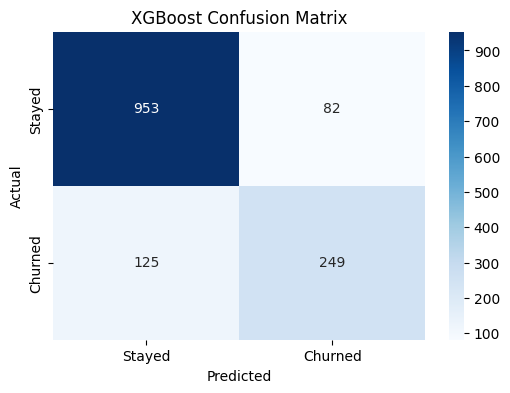

In [7]:
# Confusion Matrix Plot
y_pred_xgb = xgb_model.predict(X_test)
cm = confusion_matrix(y_test, y_pred_xgb)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Stayed', 'Churned'], yticklabels=['Stayed', 'Churned'])
plt.title('XGBoost Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

/Users/seemasultana/churn-prediction/churn_env/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


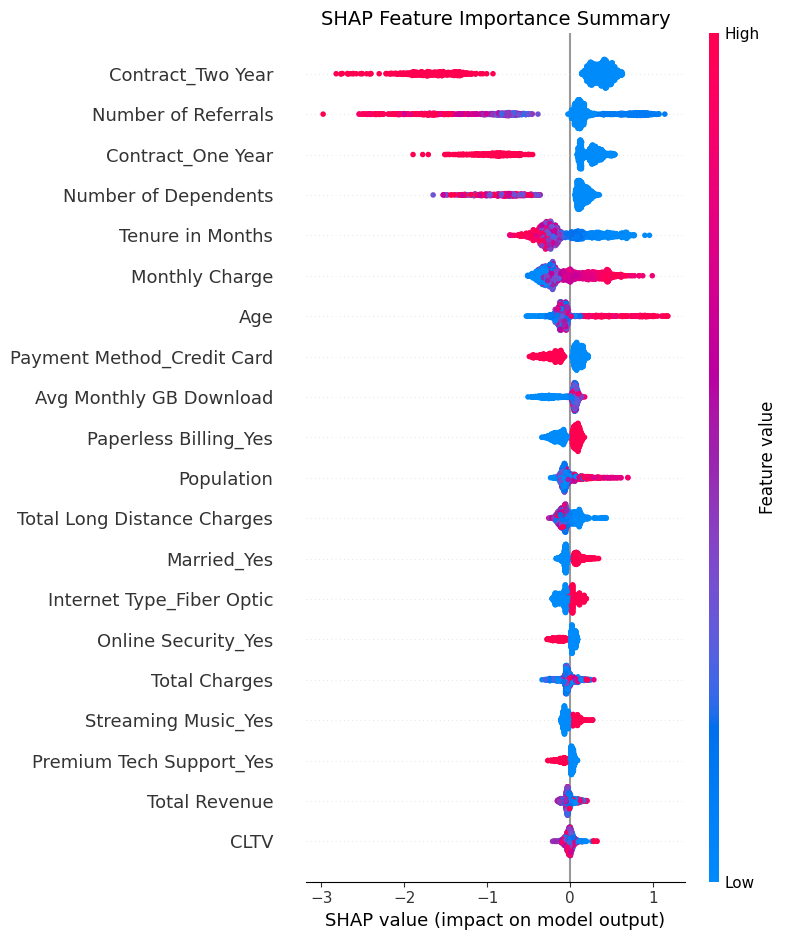

In [8]:
import shap

# Create SHAP Tree Explainer on trained XGBoost model
explainer = shap.TreeExplainer(xgb_model)
shap_values = explainer.shap_values(X_test)

# 1. Global Interpretability: Summary Plot showing top features driving churn overall
plt.title("SHAP Feature Importance Summary", fontsize=14)
shap.summary_plot(shap_values, X_test)

# 2. Local Interpretability: Force plot for a single customer (e.g., the first test customer)
shap.initjs()
shap.force_plot(
    explainer.expected_value, 
    shap_values[0, :], 
    X_test.iloc[0, :]
)

## 📊 Step 8: Executive Summary & Business Recommendations

Based on the SHAP values and model feature importances, we identified the primary drivers behind customer churn and formulated the following action items:

### 1. Offer-Based Incentives (Contracts)
* **Finding:** Customers on **Month-to-Month contracts** exhibit significantly higher churn probability compared to long-term contract holders.
* **Action:** Launch a targeted email/SMS campaign offering a **10–15% discount or a free trial addon** (e.g., streaming) to convert Month-to-Month users into 1-Year or 2-Year contracts.

### 2. Early-Stage Retention Focus (Tenure)
* **Finding:** The risk of churn is heavily concentrated within a customer's first **0 to 12 months** (`Tenure in Months`).
* **Action:** Implement an automated **90-day onboarding sequence**. Proactively reach out with satisfaction surveys, setup help, and check-in calls to ensure smooth early adoption.

### 3. Fiber Optic Service Strategy
* **Finding:** Customers using **Fiber Optic** internet show a higher churn rate despite high speeds, largely driven by higher `Monthly Charges`.
* **Action:** Bundle high-value features like **Premium Tech Support** or **Device Protection** for free with Fiber Optic plans to increase perceived value without cutting subscription fees directly.